# Sentinel-2 City Feature Extraction

This notebook processes Copernicus Sentinel-2 L2A TIFF files in the format:

- `..._Sentinel-2_L2A_B02_(Raw).tiff`
- `..._Sentinel-2_L2A_B03_(Raw).tiff`
- `..._Sentinel-2_L2A_B04_(Raw).tiff`
- `..._Sentinel-2_L2A_B08_(Raw).tiff`
- `..._Sentinel-2_L2A_B11_(Raw).tiff`
- `..._Sentinel-2_L2A_B12_(Raw).tiff`
- `..._Sentinel-2_L2A_NDVI.tiff`
- `..._Sentinel-2_L2A_NDWI.tiff`
- `..._Sentinel-2_L2A_Scene_classification_map_.tiff`

It extracts city-level satellite features such as NDVI, NDWI, NDBI, BSI, vegetation coverage, water coverage, built-up coverage, bare soil coverage, and Scene Classification statistics.

## Important
By default, the notebook processes the entire downloaded TIFF extent. If the export extends beyond the actual city boundary, set `BOUNDARY_FILE` to a GeoJSON/Shapefile and the notebook will clip all analysis to that boundary.


In [98]:
# Run once if packages are missing
# !pip install rasterio numpy pandas matplotlib geopandas

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import rasterio
from rasterio.enums import Resampling
from rasterio.warp import reproject
from rasterio.mask import mask
import matplotlib.pyplot as plt

try:
    import geopandas as gpd
except ImportError:
    gpd = None

warnings.filterwarnings("ignore")
print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Configuration
Change these values for the city you want to process.

In [99]:
# ============================================================
# CITY CONFIGURATION
# ============================================================

CITY_NAME = "Delhi"

# Folder containing the Sentinel TIFF files
CITY_FOLDER = Path(r"/content/Delhi")

# Optional city boundary file (.geojson, .shp, etc.)
# Set to None to process the complete TIFF extent.
BOUNDARY_FILE = None
# Example:
# BOUNDARY_FILE = Path(r"boundaries/delhi.geojson")

# Output folder
OUTPUT_FOLDER = Path("output/Delhi")
OUTPUT_FOLDER.mkdir(parents=True, exist_ok=True)

print(f"City: {CITY_NAME}")
print(f"City folder: {CITY_FOLDER}")
print(f"Boundary: {BOUNDARY_FILE}")
print(f"Output folder: {OUTPUT_FOLDER}")

City: Delhi
City folder: /content/Delhi
Boundary: None
Output folder: output/Delhi


## 2. Find and detect the Sentinel files automatically

In [100]:
if not CITY_FOLDER.exists():
    raise FileNotFoundError(
        f"City folder not found: {CITY_FOLDER.resolve()}\n"
        "Update CITY_FOLDER in the configuration cell."
    )

tiff_files = sorted(
    list(CITY_FOLDER.glob("*.tif")) +
    list(CITY_FOLDER.glob("*.tiff"))
)

print(f"Found {len(tiff_files)} TIFF files:\n")
for file in tiff_files:
    print(file.name)

if not tiff_files:
    raise FileNotFoundError("No .tif or .tiff files found in CITY_FOLDER.")

Found 11 TIFF files:

2026-07-12-00_00_2026-07-12-23_59_Sentinel-2_L2A_B02_(Raw).tiff
2026-07-12-00_00_2026-07-12-23_59_Sentinel-2_L2A_B03_(Raw).tiff
2026-07-12-00_00_2026-07-12-23_59_Sentinel-2_L2A_B04_(Raw).tiff
2026-07-12-00_00_2026-07-12-23_59_Sentinel-2_L2A_B08_(Raw).tiff
2026-07-12-00_00_2026-07-12-23_59_Sentinel-2_L2A_B11_(Raw).tiff
2026-07-12-00_00_2026-07-12-23_59_Sentinel-2_L2A_B12_(Raw).tiff
2026-07-12-00_00_2026-07-12-23_59_Sentinel-2_L2A_False_color.tiff
2026-07-12-00_00_2026-07-12-23_59_Sentinel-2_L2A_NDVI.tiff
2026-07-12-00_00_2026-07-12-23_59_Sentinel-2_L2A_NDWI.tiff
2026-07-12-00_00_2026-07-12-23_59_Sentinel-2_L2A_Scene_classification_map_.tiff
2026-07-12-00_00_2026-07-12-23_59_Sentinel-2_L2A_True_color.tiff


In [101]:
# ============================================================
# AUTOMATIC BAND DETECTION
# ============================================================

REQUIRED_BANDS = ["B02", "B03", "B04", "B08", "B11", "B12"]
bands = {}

for band in REQUIRED_BANDS:
    matches = [f for f in tiff_files if f"_{band}_" in f.name.upper()]
    if matches:
        bands[band] = matches[0]

missing = [band for band in REQUIRED_BANDS if band not in bands]

if missing:
    raise FileNotFoundError(f"Missing required bands: {missing}")

ndvi_file = next((f for f in tiff_files if "_NDVI" in f.name.upper()), None)
ndwi_file = next((f for f in tiff_files if "_NDWI" in f.name.upper()), None)
scl_file = next((f for f in tiff_files if "SCENE_CLASSIFICATION" in f.name.upper()), None)

print("Detected raw bands:")
for band, path in bands.items():
    print(f"  {band}: {path.name}")

print(f"\nNDVI: {ndvi_file.name if ndvi_file else 'Not found'}")
print(f"NDWI: {ndwi_file.name if ndwi_file else 'Not found'}")
print(f"SCL : {scl_file.name if scl_file else 'Not found'}")

Detected raw bands:
  B02: 2026-07-12-00_00_2026-07-12-23_59_Sentinel-2_L2A_B02_(Raw).tiff
  B03: 2026-07-12-00_00_2026-07-12-23_59_Sentinel-2_L2A_B03_(Raw).tiff
  B04: 2026-07-12-00_00_2026-07-12-23_59_Sentinel-2_L2A_B04_(Raw).tiff
  B08: 2026-07-12-00_00_2026-07-12-23_59_Sentinel-2_L2A_B08_(Raw).tiff
  B11: 2026-07-12-00_00_2026-07-12-23_59_Sentinel-2_L2A_B11_(Raw).tiff
  B12: 2026-07-12-00_00_2026-07-12-23_59_Sentinel-2_L2A_B12_(Raw).tiff

NDVI: 2026-07-12-00_00_2026-07-12-23_59_Sentinel-2_L2A_NDVI.tiff
NDWI: 2026-07-12-00_00_2026-07-12-23_59_Sentinel-2_L2A_NDWI.tiff
SCL : 2026-07-12-00_00_2026-07-12-23_59_Sentinel-2_L2A_Scene_classification_map_.tiff


## 3. Inspect raster metadata

In [102]:
metadata = []

for name, path in bands.items():
    with rasterio.open(path) as src:
        metadata.append({
            "Band": name,
            "Width": src.width,
            "Height": src.height,
            "CRS": str(src.crs),
            "Resolution X": src.res[0],
            "Resolution Y": src.res[1],
            "Data Type": src.dtypes[0],
            "NoData": src.nodata,
            "Bounds": str(src.bounds)
        })

metadata_df = pd.DataFrame(metadata)
display(metadata_df)

,Band,Width,Height,CRS,Resolution X,Resolution Y,Data Type,NoData,Bounds
0,B02,2500,1901,EPSG:4326,0.000149,0.000131,uint16,None,"BoundingBox(left=77.04677581787111, bottom=28...."
1,B03,2500,1901,EPSG:4326,0.000149,0.000131,uint16,None,"BoundingBox(left=77.04677581787111, bottom=28...."
2,B04,2500,1901,EPSG:4326,0.000149,0.000131,uint16,None,"BoundingBox(left=77.04677581787111, bottom=28...."
3,B08,2500,1901,EPSG:4326,0.000149,0.000131,uint16,None,"BoundingBox(left=77.04677581787111, bottom=28...."
4,B11,2500,1901,EPSG:4326,0.000149,0.000131,uint16,None,"BoundingBox(left=77.04677581787111, bottom=28...."
5,B12,2500,1901,EPSG:4326,0.000149,0.000131,uint16,None,"BoundingBox(left=77.04677581787111, bottom=28...."


## 4. Load the city boundary (optional)
If `BOUNDARY_FILE = None`, the full downloaded TIFF extent is used.

In [103]:
boundary_gdf = None

if BOUNDARY_FILE is not None:
    if gpd is None:
        raise ImportError("geopandas is required for boundary clipping. Run: pip install geopandas")
    if not Path(BOUNDARY_FILE).exists():
        raise FileNotFoundError(f"Boundary file not found: {BOUNDARY_FILE}")

    boundary_gdf = gpd.read_file(BOUNDARY_FILE)
    print(f"Loaded boundary with {len(boundary_gdf)} feature(s)")
    print("Boundary CRS:", boundary_gdf.crs)
else:
    print("No boundary file supplied. Using full TIFF extent.")

No boundary file supplied. Using full TIFF extent.


## 5. Load and align all bands
B08 is used as the reference grid. Other bands are automatically resampled/aligned when required.

In [104]:
REFERENCE_BAND = "B08"

def load_band_as_reference(raster_path, reference_path, boundary=None, resampling=Resampling.bilinear):
    # Read reference metadata
    with rasterio.open(reference_path) as ref:
        ref_crs = ref.crs
        ref_transform = ref.transform
        ref_width = ref.width
        ref_height = ref.height

        if boundary is not None:
            boundary_ref = boundary.to_crs(ref_crs)
            geometries = [geom.__geo_interface__ for geom in boundary_ref.geometry]

            # Crop the reference raster first to define the analysis grid
            ref_crop, ref_crop_transform = mask(ref, geometries, crop=True, filled=False)
            ref_height = ref_crop.shape[1]
            ref_width = ref_crop.shape[2]
            ref_transform = ref_crop_transform

    with rasterio.open(raster_path) as src:
        source = src.read(1).astype(np.float32)

        # Reproject boundary clipping by using destination grid
        destination = np.full((ref_height, ref_width), np.nan, dtype=np.float32)

        reproject(
            source=source,
            destination=destination,
            src_transform=src.transform,
            src_crs=src.crs,
            src_nodata=src.nodata,
            dst_transform=ref_transform,
            dst_crs=ref_crs,
            dst_nodata=np.nan,
            resampling=resampling
        )

    return destination, {
        "height": ref_height,
        "width": ref_width,
        "transform": ref_transform,
        "crs": ref_crs
    }

# Load all raw bands aligned to B08
band_data = {}
reference_profile = None

for band_name, band_path in bands.items():
    print(f"Loading and aligning {band_name}...")
    data, profile = load_band_as_reference(
        band_path,
        bands[REFERENCE_BAND],
        boundary=boundary_gdf,
        resampling=Resampling.bilinear
    )
    band_data[band_name] = data
    reference_profile = profile

print("\nAll bands loaded successfully.")
print("Analysis shape:", band_data[REFERENCE_BAND].shape)
print("Analysis CRS:", reference_profile["crs"])

Loading and aligning B02...
Loading and aligning B03...
Loading and aligning B04...
Loading and aligning B08...
Loading and aligning B11...
Loading and aligning B12...

All bands loaded successfully.
Analysis shape: (1901, 2500)
Analysis CRS: EPSG:4326


In [105]:
B02 = band_data["B02"]
B03 = band_data["B03"]
B04 = band_data["B04"]
B08 = band_data["B08"]
B11 = band_data["B11"]
B12 = band_data["B12"]

print("Raw band value summary:")
for name, data in band_data.items():
    valid = data[np.isfinite(data)]
    print(f"{name}: min={np.min(valid):.2f}, max={np.max(valid):.2f}, mean={np.mean(valid):.2f}")

Raw band value summary:
B02: min=0.00, max=65535.00, mean=5404.45
B03: min=0.00, max=65535.00, mean=9024.91
B04: min=0.00, max=65535.00, mean=10256.27
B08: min=4909.00, max=65535.00, mean=18927.34
B11: min=7438.00, max=65535.00, mean=16338.62
B12: min=5656.00, max=65535.00, mean=12270.22


## 6. Load Scene Classification Map and create a valid-pixel mask

In [106]:
# Basic validity across all required bands
valid_mask = (
    np.isfinite(B02) &
    np.isfinite(B03) &
    np.isfinite(B04) &
    np.isfinite(B08) &
    np.isfinite(B11) &
    np.isfinite(B12)
)

scl = None

if scl_file is not None:
    scl_float, _ = load_band_as_reference(
        scl_file,
        bands[REFERENCE_BAND],
        boundary=boundary_gdf,
        resampling=Resampling.nearest
    )
    scl = np.where(np.isfinite(scl_float), scl_float, -999).astype(np.int16)

    unique_values, counts = np.unique(scl[scl != -999], return_counts=True)
    print("SCL classes found:")
    for value, count in zip(unique_values, counts):
        print(f"  Class {value}: {count:,} pixels")

    # Sentinel-2 SCL classes removed from analysis:
    # 0 No Data, 1 Saturated/Defective, 3 Cloud Shadow,
    # 8 Cloud Medium Probability, 9 Cloud High Probability,
    # 10 Thin Cirrus, 11 Snow/Ice
    invalid_scl_classes = [0, 1, 3, 8, 9, 10, 11]
    valid_mask &= ~np.isin(scl, invalid_scl_classes)
else:
    print("No SCL found. Using raster validity only.")

print(f"Total pixels: {valid_mask.size:,}")
print(f"Valid pixels: {valid_mask.sum():,}")
print(f"Valid pixel percentage: {valid_mask.mean() * 100:.2f}%")

SCL classes found:
  Class -16191: 59 pixels
  Class -1: 4,694,523 pixels
  Class 0: 57,917 pixels
  Class 25700: 1 pixels
Total pixels: 4,752,500
Valid pixels: 4,694,583
Valid pixel percentage: 98.78%


## 7. Calculate spectral indices

In [107]:
def safe_index(numerator, denominator, valid_mask):
    with np.errstate(divide="ignore", invalid="ignore"):
        result = numerator / denominator
    result = result.astype(np.float32)
    result[~np.isfinite(result)] = np.nan
    result[~valid_mask] = np.nan
    return np.clip(result, -1, 1)

# NDVI = (NIR - RED) / (NIR + RED)
NDVI = safe_index(B08 - B04, B08 + B04, valid_mask)

# NDWI = (GREEN - NIR) / (GREEN + NIR)
NDWI = safe_index(B03 - B08, B03 + B08, valid_mask)

# NDBI = (SWIR - NIR) / (SWIR + NIR)
NDBI = safe_index(B11 - B08, B11 + B08, valid_mask)

# BSI = ((SWIR + RED) - (NIR + BLUE)) / ((SWIR + RED) + (NIR + BLUE))
BSI = safe_index(
    (B11 + B04) - (B08 + B02),
    (B11 + B04) + (B08 + B02),
    valid_mask
)

print("NDVI, NDWI, NDBI and BSI calculated successfully.")

NDVI, NDWI, NDBI and BSI calculated successfully.


## 8. Visualize the indices

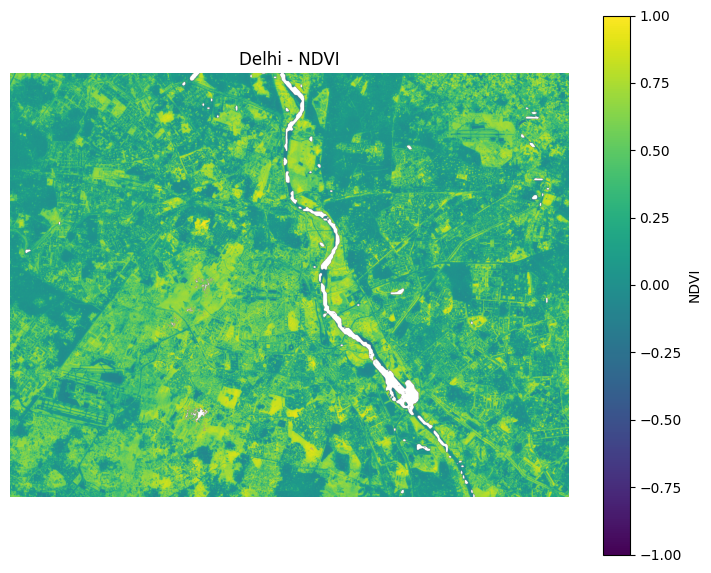

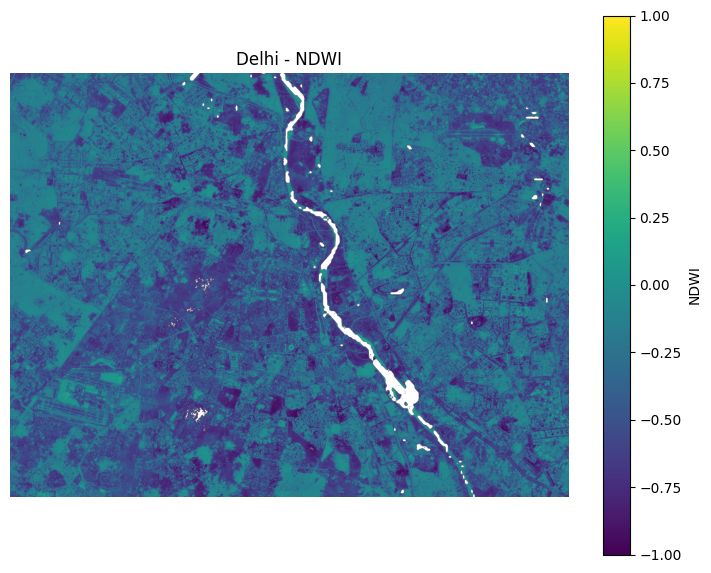

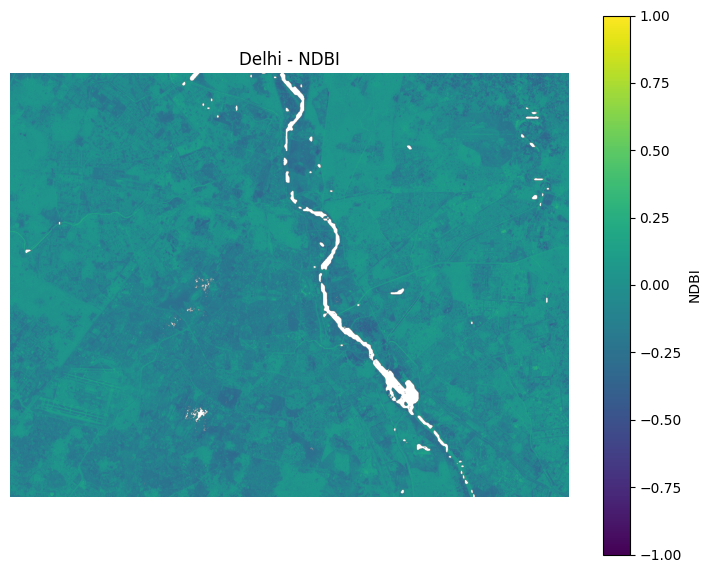

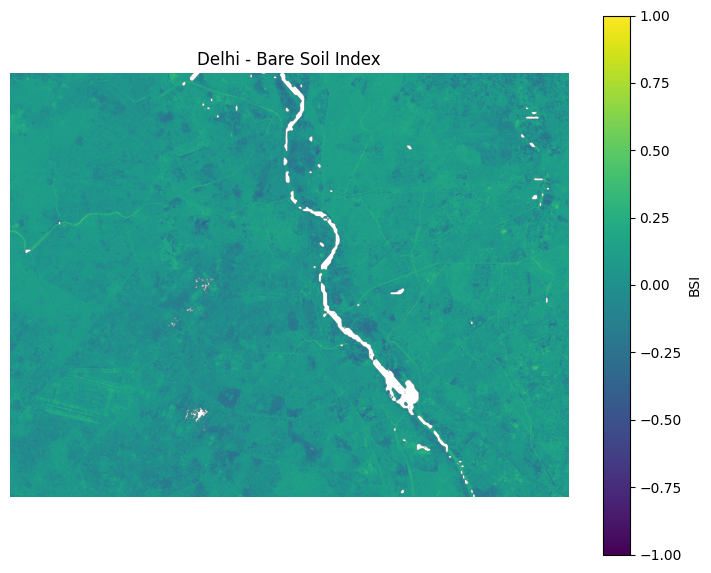

In [108]:
def plot_raster(data, title, label):
    plt.figure(figsize=(9, 7))
    image = plt.imshow(data, vmin=-1, vmax=1)
    plt.colorbar(image, label=label)
    plt.title(title)
    plt.axis("off")
    plt.show()

plot_raster(NDVI, f"{CITY_NAME} - NDVI", "NDVI")
plot_raster(NDWI, f"{CITY_NAME} - NDWI", "NDWI")
plot_raster(NDBI, f"{CITY_NAME} - NDBI", "NDBI")
plot_raster(BSI, f"{CITY_NAME} - Bare Soil Index", "BSI")

## 9. Classify vegetation, water, built-up land and bare soil
These are transparent threshold-based proxy indicators, suitable for city-level feature extraction.

In [109]:
# ============================================================
# THRESHOLDS
# Adjust later if visual inspection suggests they need tuning.
# ============================================================

VEGETATION_THRESHOLD = 0.20
DENSE_VEGETATION_THRESHOLD = 0.50
WATER_THRESHOLD = 0.00
BUILTUP_NDBI_THRESHOLD = 0.00
LOW_NDVI_THRESHOLD = 0.30
BARE_SOIL_BSI_THRESHOLD = 0.00

analysis_pixels = np.isfinite(NDVI)
valid_pixels = analysis_pixels.sum()

low_vegetation_mask = (NDVI < VEGETATION_THRESHOLD) & analysis_pixels
moderate_vegetation_mask = (
    (NDVI >= VEGETATION_THRESHOLD) &
    (NDVI < DENSE_VEGETATION_THRESHOLD)
)
dense_vegetation_mask = NDVI >= DENSE_VEGETATION_THRESHOLD
vegetation_mask = NDVI >= VEGETATION_THRESHOLD

water_mask = (NDWI > WATER_THRESHOLD) & analysis_pixels

# Built-up proxy: positive NDBI + low vegetation
builtup_mask = (
    (NDBI > BUILTUP_NDBI_THRESHOLD) &
    (NDVI < LOW_NDVI_THRESHOLD) &
    analysis_pixels
)

# Bare soil proxy: positive BSI + low vegetation, excluding built-up
bare_soil_mask = (
    (BSI > BARE_SOIL_BSI_THRESHOLD) &
    (NDVI < LOW_NDVI_THRESHOLD) &
    (~builtup_mask) &
    analysis_pixels
)

def pct(mask):
    return float(mask.sum() / valid_pixels * 100) if valid_pixels else np.nan

vegetation_pct = pct(vegetation_mask)
moderate_vegetation_pct = pct(moderate_vegetation_mask)
dense_vegetation_pct = pct(dense_vegetation_mask)
water_pct = pct(water_mask)
builtup_pct = pct(builtup_mask)
bare_soil_pct = pct(bare_soil_mask)

print(f"Vegetation: {vegetation_pct:.2f}%")
print(f"Dense vegetation: {dense_vegetation_pct:.2f}%")
print(f"Water: {water_pct:.2f}%")
print(f"Built-up proxy: {builtup_pct:.2f}%")
print(f"Bare soil proxy: {bare_soil_pct:.2f}%")

Vegetation: 57.90%
Dense vegetation: 27.74%
Water: 2.19%
Built-up proxy: 30.25%
Bare soil proxy: 19.07%


## 10. Calculate index statistics

In [110]:
def raster_statistics(data, prefix):
    values = data[np.isfinite(data)]
    return {
        f"{prefix}_mean": float(np.mean(values)),
        f"{prefix}_median": float(np.median(values)),
        f"{prefix}_std": float(np.std(values)),
        f"{prefix}_min": float(np.min(values)),
        f"{prefix}_max": float(np.max(values)),
        f"{prefix}_p25": float(np.percentile(values, 25)),
        f"{prefix}_p75": float(np.percentile(values, 75)),
    }

ndvi_stats = raster_statistics(NDVI, "ndvi")
ndwi_stats = raster_statistics(NDWI, "ndwi")
ndbi_stats = raster_statistics(NDBI, "ndbi")
bsi_stats = raster_statistics(BSI, "bsi")

pd.DataFrame([{
    **ndvi_stats,
    **ndwi_stats,
    **ndbi_stats,
    **bsi_stats
}]).T

,0
ndvi_mean,0.312850
ndvi_median,0.273372
ndvi_std,0.245680
ndvi_min,-0.487270
ndvi_max,1.000000
ndvi_p25,0.087659
ndvi_p75,0.526130
ndwi_mean,-0.372207
ndwi_median,-0.352155
ndwi_std,0.236427


## 11. Scene Classification statistics

In [111]:
scl_statistics = {}

if scl is not None:
    valid_scl = scl[scl != -999]
    total_scl = len(valid_scl)

    if total_scl:
        scl_statistics = {
            "scl_vegetation_pct": float(np.sum(valid_scl == 4) / total_scl * 100),
            "scl_bare_soil_pct": float(np.sum(valid_scl == 5) / total_scl * 100),
            "scl_water_pct": float(np.sum(valid_scl == 6) / total_scl * 100),
            "cloud_pct": float(np.sum(np.isin(valid_scl, [8, 9, 10])) / total_scl * 100),
        }

pd.DataFrame([scl_statistics]) if scl_statistics else print("No SCL statistics available.")

,scl_vegetation_pct,scl_bare_soil_pct,scl_water_pct,cloud_pct
0,0.0,0.0,0.0,0.0


## 12. Land-cover diversity and optional environmental score

In [112]:
# Shannon entropy across the four extracted landscape proportions.
land_components = np.array([
    vegetation_pct,
    water_pct,
    builtup_pct,
    bare_soil_pct
], dtype=float)

land_components = land_components[land_components > 0]

if len(land_components) > 0:
    probabilities = land_components / land_components.sum()
    land_cover_diversity = float(-np.sum(probabilities * np.log(probabilities)))
else:
    land_cover_diversity = np.nan

# Experimental/demo score. Raw features remain the primary output.
green_score = np.clip(vegetation_pct, 0, 100)
water_score = np.clip(water_pct * 5, 0, 100)
builtup_penalty = np.clip(builtup_pct, 0, 100)
bare_soil_penalty = np.clip(bare_soil_pct, 0, 100)

environmental_score = float(np.clip(
    0.45 * green_score +
    0.15 * water_score +
    0.20 * (100 - builtup_penalty) +
    0.20 * (100 - bare_soil_penalty),
    0, 100
))

print(f"Land-cover diversity: {land_cover_diversity:.4f}")
print(f"Experimental environmental score: {environmental_score:.2f}")

Land-cover diversity: 1.0751
Experimental environmental score: 57.83


## 13. Create the final city feature table

In [113]:
city_features = {
    "city": CITY_NAME,
    **ndvi_stats,
    **ndwi_stats,
    **ndbi_stats,
    **bsi_stats,

    "vegetation_pct": vegetation_pct,
    "moderate_vegetation_pct": moderate_vegetation_pct,
    "dense_vegetation_pct": dense_vegetation_pct,

    "water_pct": water_pct,
    "builtup_pct": builtup_pct,
    "bare_soil_pct": bare_soil_pct,

    "land_cover_diversity": land_cover_diversity,
    "environmental_score_experimental": environmental_score,
    "valid_pixel_pct": float(valid_mask.mean() * 100),

    "boundary_clipped": BOUNDARY_FILE is not None
}

city_features.update(scl_statistics)

city_df = pd.DataFrame([city_features])

numeric_columns = city_df.select_dtypes(include=np.number).columns
city_df[numeric_columns] = city_df[numeric_columns].round(4)

display(city_df)

,city,ndvi_mean,ndvi_median,ndvi_std,ndvi_min,ndvi_max,ndvi_p25,ndvi_p75,ndwi_mean,ndwi_median,...,builtup_pct,bare_soil_pct,land_cover_diversity,environmental_score_experimental,valid_pixel_pct,boundary_clipped,scl_vegetation_pct,scl_bare_soil_pct,scl_water_pct,cloud_pct
0,Delhi,0.3129,0.2734,0.2457,-0.4873,1.0,0.0877,0.5261,-0.3722,-0.3522,...,30.2453,19.0746,1.0751,57.8335,98.7813,False,0.0,0.0,0.0,0.0


## 14. Save the feature table as CSV

In [114]:
output_csv = OUTPUT_FOLDER / f"{CITY_NAME.lower().replace(' ', '_')}_satellite_features.csv"
city_df.to_csv(output_csv, index=False)

print("Feature extraction complete.")
print(f"CSV saved to: {output_csv.resolve()}")

Feature extraction complete.
CSV saved to: /content/output/Delhi/delhi_satellite_features.csv


## 15. Save calculated index rasters

In [115]:
def save_raster(data, output_path):
    profile = {
        "driver": "GTiff",
        "height": reference_profile["height"],
        "width": reference_profile["width"],
        "count": 1,
        "dtype": "float32",
        "crs": reference_profile["crs"],
        "transform": reference_profile["transform"],
        "nodata": np.nan,
        "compress": "lzw"
    }

    with rasterio.open(output_path, "w", **profile) as dst:
        dst.write(data.astype(np.float32), 1)

city_slug = CITY_NAME.lower().replace(" ", "_")

save_raster(NDVI, OUTPUT_FOLDER / f"{city_slug}_ndvi_calculated.tiff")
save_raster(NDWI, OUTPUT_FOLDER / f"{city_slug}_ndwi_calculated.tiff")
save_raster(NDBI, OUTPUT_FOLDER / f"{city_slug}_ndbi.tiff")
save_raster(BSI, OUTPUT_FOLDER / f"{city_slug}_bsi.tiff")

print("Calculated index TIFFs saved successfully.")

Calculated index TIFFs saved successfully.


## 16. Final summary

In [116]:
print("=" * 65)
print(f"SATELLITE FEATURE SUMMARY: {CITY_NAME.upper()}")
print("=" * 65)

summary_items = {
    "Mean NDVI": ndvi_stats["ndvi_mean"],
    "Vegetation Coverage (%)": vegetation_pct,
    "Dense Vegetation (%)": dense_vegetation_pct,
    "Mean NDWI": ndwi_stats["ndwi_mean"],
    "Water Coverage (%)": water_pct,
    "Mean NDBI": ndbi_stats["ndbi_mean"],
    "Built-up Proxy (%)": builtup_pct,
    "Mean BSI": bsi_stats["bsi_mean"],
    "Bare Soil Proxy (%)": bare_soil_pct,
    "Land Cover Diversity": land_cover_diversity,
    "Environmental Score (Experimental)": environmental_score,
    "Valid Pixel (%)": valid_mask.mean() * 100
}

for key, value in summary_items.items():
    print(f"{key}: {value:.4f}" if abs(value) < 10 else f"{key}: {value:.2f}")

print("=" * 65)
print("\nPrimary output:")
print(output_csv.resolve())

SATELLITE FEATURE SUMMARY: DELHI
Mean NDVI: 0.3129
Vegetation Coverage (%): 57.90
Dense Vegetation (%): 27.74
Mean NDWI: -0.3722
Water Coverage (%): 2.1929
Mean NDBI: -0.0653
Built-up Proxy (%): 30.25
Mean BSI: 0.0448
Bare Soil Proxy (%): 19.07
Land Cover Diversity: 1.0751
Environmental Score (Experimental): 57.83
Valid Pixel (%): 98.78

Primary output:
/content/output/Delhi/delhi_satellite_features.csv
